# Mini ML project: NBA Game Outcome Prediction with Machine Learning

In this mini project, I will try to use historical NBA game data to predict future outcomes of games. I will first try to predict if the home team will win a game in a classification case and try to improve it with feature engineering. Later, I will try to predict the score difference in a regression task. Part 1 (Baseline Classification Model) will be the part that follows the structure described in the project brief: in the other two sections, I did some further experimentations to improve my understanding.

## Index

1. **Baseline Classification Model**  
   Built a ML pipelin to predict if the home team will win. 

2. **Improved Classification Model**  
   Tried to improve the model from part 1 by adding engineered features.

3. **Regression Extension**  
   Tried to predict the point difference betweeen the two teams with regression models.

## Part 1: Basline Model

### 1.1. Problem Framing

The goal of the firs part of the project is to build a model that is able to predict who will win in an NBA game. To be precise, I will predict if the home team wins or not.
For this, I will use the target variable `HOME_TEAM_WINS` within a binary classification problem:

1 → home team wins

0 → home team loses

It is a binary classification problem since the model chooses between one of two answers rather than from a continuous numerical value.

The model learns from historical game data to predict games from the test dataset. Such a model could be very useful for applications such as sports analysis, team management, or betting applications. It helps in the process of estimating the outcomes of games before a match starts and, therefore, allows stakeholders to make more informed decisions in the previously mentioned areas. I follow a standard ML pipeline: data loading, preprocessing, training, evaluation, and interpretation.

### 1.2. Load & Explore Data

As we can see from the outputs below, the dataset contains 26'651 NBA games with 20 columns each. This includes data such as game metadata, team IDs, numerical performance statistics... both for home and away teams. Most of the values are numerical. Only a few are categorical/identifier columns. `HOME_TEAM_WINS` is our target variable and already encoded as a binary variable. I can see that there is a small imbalance. Home teams win slightly more than away teams. 

This all sounds very good, but one issue that I will run into with this dataset is that almost all interesting columns would cause data leakage if I used them as features. For example, if I used the points of the home team and the points of the away team, the model would have no problem predicting who won the game, since it would simply have to compare the values. From my research, the most common way to avoid this data leakage in our case is to perform some feature engineering. To do this, I have added a new section (1.2.1 Feature Engineering) to explore this.

In [14]:
import pandas as pd

df = pd.read_csv("../data/games.csv")
df.columns

Index(['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID',
       'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home',
       'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away',
       'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away',
       'REB_away', 'HOME_TEAM_WINS'],
      dtype='str')

In [16]:
df.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26651 entries, 0 to 26650
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GAME_DATE_EST     26651 non-null  str    
 1   GAME_ID           26651 non-null  int64  
 2   GAME_STATUS_TEXT  26651 non-null  str    
 3   HOME_TEAM_ID      26651 non-null  int64  
 4   VISITOR_TEAM_ID   26651 non-null  int64  
 5   SEASON            26651 non-null  int64  
 6   TEAM_ID_home      26651 non-null  int64  
 7   PTS_home          26552 non-null  float64
 8   FG_PCT_home       26552 non-null  float64
 9   FT_PCT_home       26552 non-null  float64
 10  FG3_PCT_home      26552 non-null  float64
 11  AST_home          26552 non-null  float64
 12  REB_home          26552 non-null  float64
 13  TEAM_ID_away      26651 non-null  int64  
 14  PTS_away          26552 non-null  float64
 15  FG_PCT_away       26552 non-null  float64
 16  FT_PCT_away       26552 non-null  float64
 17  FG3_

In [19]:
df.describe()

,GAME_ID,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
count,2.665100e+04,2.665100e+04,2.665100e+04,26651.000000,2.665100e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,2.665100e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26651.000000
mean,2.175487e+07,1.610613e+09,1.610613e+09,2012.113879,1.610613e+09,103.455898,0.460735,0.760377,0.356023,22.823441,43.374284,1.610613e+09,100.639876,0.449732,0.758816,0.349489,21.496271,42.113249,0.587032
std,5.570189e+06,8.638670e+00,8.659299e+00,5.587031,8.638670e+00,13.283370,0.056676,0.100677,0.111164,5.193308,6.625769,8.659299e+00,13.435868,0.055551,0.103429,0.109441,5.160596,6.533039,0.492376
min,1.030000e+07,1.610613e+09,1.610613e+09,2003.000000,1.610613e+09,36.000000,0.250000,0.143000,0.000000,6.000000,15.000000,1.610613e+09,33.000000,0.244000,0.143000,0.000000,4.000000,19.000000,0.000000
25%,2.070001e+07,1.610613e+09,1.610613e+09,2007.000000,1.610613e+09,94.000000,0.422000,0.697000,0.286000,19.000000,39.000000,1.610613e+09,91.000000,0.412000,0.692000,0.278000,18.000000,38.000000,0.000000
50%,2.120076e+07,1.610613e+09,1.610613e+09,2012.000000,1.610613e+09,103.000000,0.460000,0.765000,0.357000,23.000000,43.000000,1.610613e+09,100.000000,0.449000,0.765000,0.350000,21.000000,42.000000,1.000000
75%,2.180005e+07,1.610613e+09,1.610613e+09,2017.000000,1.610613e+09,112.000000,0.500000,0.833000,0.429000,26.000000,48.000000,1.610613e+09,110.000000,0.487000,0.833000,0.419000,25.000000,46.000000,1.000000
max,5.210021e+07,1.610613e+09,1.610613e+09,2022.000000,1.610613e+09,168.000000,0.684000,1.000000,1.000000,50.000000,72.000000,1.610613e+09,168.000000,0.687000,1.000000,1.000000,46.000000,81.000000,1.000000


In [7]:
df.isnull().sum()

GAME_DATE_EST        0
GAME_ID              0
GAME_STATUS_TEXT     0
HOME_TEAM_ID         0
VISITOR_TEAM_ID      0
SEASON               0
TEAM_ID_home         0
PTS_home            99
FG_PCT_home         99
FT_PCT_home         99
FG3_PCT_home        99
AST_home            99
REB_home            99
TEAM_ID_away         0
PTS_away            99
FG_PCT_away         99
FT_PCT_away         99
FG3_PCT_away        99
AST_away            99
REB_away            99
HOME_TEAM_WINS       0
dtype: int64

In [8]:
df['HOME_TEAM_WINS'].value_counts()

HOME_TEAM_WINS
1    15645
0    11006
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


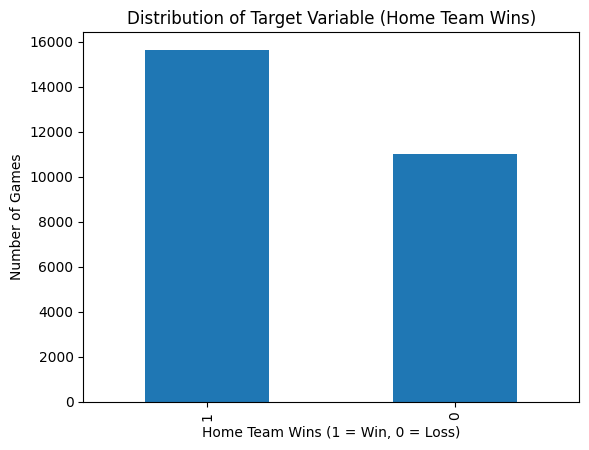

In [9]:
import matplotlib.pyplot as plt

df['HOME_TEAM_WINS'].value_counts().plot(kind='bar')
plt.title('Distribution of Target Variable (Home Team Wins)')
plt.xlabel('Home Team Wins (1 = Win, 0 = Loss)')
plt.ylabel('Number of Games')
plt.show()

#### 1.2.1. Feature Engineering

In addition to the standard features that we take over from the `games.csv` file (`GAME_DATE_EST`, `SEASON`, `HOME_TEAM_ID`, `VISITOR_TEAM_ID`, `HOME_TEAM_WINS`) we compute the folowing ones: 
- `HOME_W_PCT`: win percentage of the home team before the game (overall team strength)
- `AWAY_W_PCT`: win percentage of the away team before the game
- `DIFF_W_PCT`: difference in win percentage between home and away team (relative strength)
- `HOME_HOME_WINS`: number of wins by the home team in previous home games
- `HOME_HOME_LOSSES`: number of losses by the home team in previous home games
- `AWAY_ROAD_WINS`: number of wins by the away team in previous away games
- `AWAY_ROAD_LOSSES`: number of losses by the away team in previous away games
- `HOME_HOME_WIN_PCT`: home team’s win percentage in home games (home-court performance)
- `AWAY_ROAD_WIN_PCT`: away team’s win percentage in away games (away performance)
- `DIFF_HOME_ROAD_WIN_PCT`: difference between home team’s home performance and away team’s away performance
- `HOME_GAMES_PLAYED`: total number of home games played before the match (experience / sample size)
- `AWAY_GAMES_PLAYED`: total number of away games played before the match
- `DIFF_GAMES_PLAYED`: difference in total games played between home and away team

In [24]:
import pandas as pd

# Load data
games = pd.read_csv("../data/games.csv")
ranking = pd.read_csv("../data/ranking.csv")

# Convert dates
games["GAME_DATE_EST"] = pd.to_datetime(games["GAME_DATE_EST"])
ranking["STANDINGSDATE"] = pd.to_datetime(ranking["STANDINGSDATE"])

# Keep completed games only
games = games[games["GAME_STATUS_TEXT"] == "Final"].copy()

# Sort for merge_asof
games = games.sort_values("GAME_DATE_EST")
ranking = ranking.sort_values("STANDINGSDATE")

# Merge latest available ranking for home team before game date
home_df = pd.merge_asof(
    games,
    ranking,
    left_on="GAME_DATE_EST",
    right_on="STANDINGSDATE",
    left_by="HOME_TEAM_ID",
    right_by="TEAM_ID",
    direction="backward"
)

# Merge latest available ranking for away team before game date
full_df = pd.merge_asof(
    home_df,
    ranking,
    left_on="GAME_DATE_EST",
    right_on="STANDINGSDATE",
    left_by="VISITOR_TEAM_ID",
    right_by="TEAM_ID",
    direction="backward",
    suffixes=("_HOME", "_AWAY")
)

# Helper to split records like '10-5'
def split_record(record):
    if isinstance(record, str) and "-" in record:
        wins, losses = record.split("-")
        return int(wins), int(losses)
    return 0, 0

# Parse home and road records
full_df[["HOME_HOME_WINS", "HOME_HOME_LOSSES"]] = full_df["HOME_RECORD_HOME"].apply(
    lambda x: pd.Series(split_record(x))
)

full_df[["AWAY_ROAD_WINS", "AWAY_ROAD_LOSSES"]] = full_df["ROAD_RECORD_AWAY"].apply(
    lambda x: pd.Series(split_record(x))
)

# Create engineered features
full_df["HOME_W_PCT"] = full_df["W_PCT_HOME"]
full_df["AWAY_W_PCT"] = full_df["W_PCT_AWAY"]
full_df["DIFF_W_PCT"] = full_df["HOME_W_PCT"] - full_df["AWAY_W_PCT"]

full_df["HOME_HOME_WIN_PCT"] = (
    full_df["HOME_HOME_WINS"] /
    (full_df["HOME_HOME_WINS"] + full_df["HOME_HOME_LOSSES"]).replace(0, pd.NA)
)

full_df["AWAY_ROAD_WIN_PCT"] = (
    full_df["AWAY_ROAD_WINS"] /
    (full_df["AWAY_ROAD_WINS"] + full_df["AWAY_ROAD_LOSSES"]).replace(0, pd.NA)
)

full_df["DIFF_HOME_ROAD_WIN_PCT"] = (
    full_df["HOME_HOME_WIN_PCT"] - full_df["AWAY_ROAD_WIN_PCT"]
)

full_df["HOME_GAMES_PLAYED"] = full_df["HOME_HOME_WINS"] + full_df["HOME_HOME_LOSSES"]
full_df["AWAY_GAMES_PLAYED"] = full_df["AWAY_ROAD_WINS"] + full_df["AWAY_ROAD_LOSSES"]
full_df["DIFF_GAMES_PLAYED"] = full_df["HOME_GAMES_PLAYED"] - full_df["AWAY_GAMES_PLAYED"]

# Final simplified dataset
engineered_df = full_df[
    [
        "GAME_DATE_EST",
        "SEASON",
        "HOME_TEAM_ID",
        "VISITOR_TEAM_ID",
        "HOME_TEAM_WINS",
        "HOME_W_PCT",
        "AWAY_W_PCT",
        "DIFF_W_PCT",
        "HOME_HOME_WINS",
        "HOME_HOME_LOSSES",
        "AWAY_ROAD_WINS",
        "AWAY_ROAD_LOSSES",
        "HOME_HOME_WIN_PCT",
        "AWAY_ROAD_WIN_PCT",
        "DIFF_HOME_ROAD_WIN_PCT",
        "HOME_GAMES_PLAYED",
        "AWAY_GAMES_PLAYED",
        "DIFF_GAMES_PLAYED",
    ]
].copy()

engineered_df.head()

,GAME_DATE_EST,SEASON,HOME_TEAM_ID,VISITOR_TEAM_ID,HOME_TEAM_WINS,HOME_W_PCT,AWAY_W_PCT,DIFF_W_PCT,HOME_HOME_WINS,HOME_HOME_LOSSES,AWAY_ROAD_WINS,AWAY_ROAD_LOSSES,HOME_HOME_WIN_PCT,AWAY_ROAD_WIN_PCT,DIFF_HOME_ROAD_WIN_PCT,HOME_GAMES_PLAYED,AWAY_GAMES_PLAYED,DIFF_GAMES_PLAYED
0,2003-10-05,2003,1610612762,1610612742,1,0.0,0.0,0.0,0,0,0,0,<NA>,<NA>,<NA>,0,0,0
1,2003-10-06,2003,1610612763,1610612749,1,0.0,0.0,0.0,0,0,0,0,<NA>,<NA>,<NA>,0,0,0
2,2003-10-07,2003,1610612764,1610612752,1,0.0,0.0,0.0,0,0,0,0,<NA>,<NA>,<NA>,0,0,0
3,2003-10-07,2003,1610612758,1610612746,1,0.0,0.0,0.0,0,0,0,0,<NA>,<NA>,<NA>,0,0,0
4,2003-10-07,2003,1610612757,1610612745,1,0.0,0.0,0.0,0,0,0,0,<NA>,<NA>,<NA>,0,0,0


#### 1.2.2. Graphs

I have added a correlation matrix below to get some further insights in to the relationship between the new engineered featuers and the target variable.

After that I also included a graph that shows the home team rate over the seasons

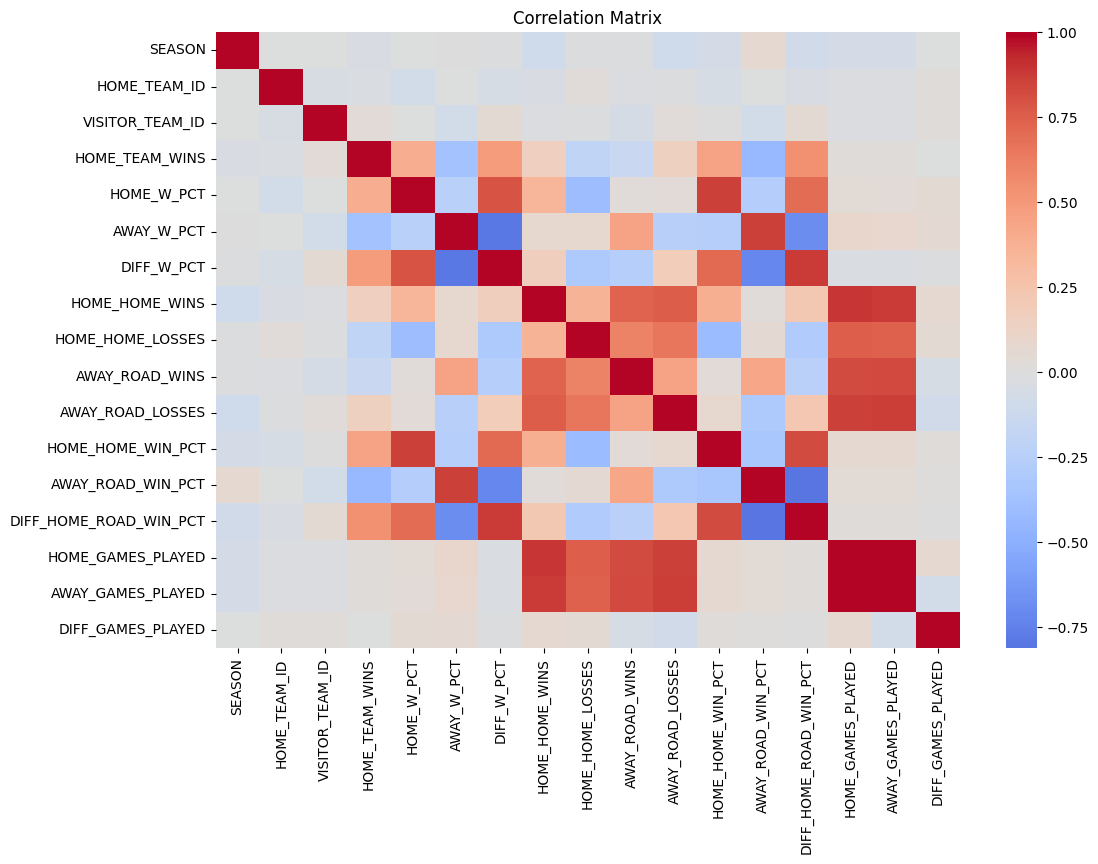

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
corr = engineered_df.drop(columns=["GAME_DATE_EST"]).corr()

# Plot correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

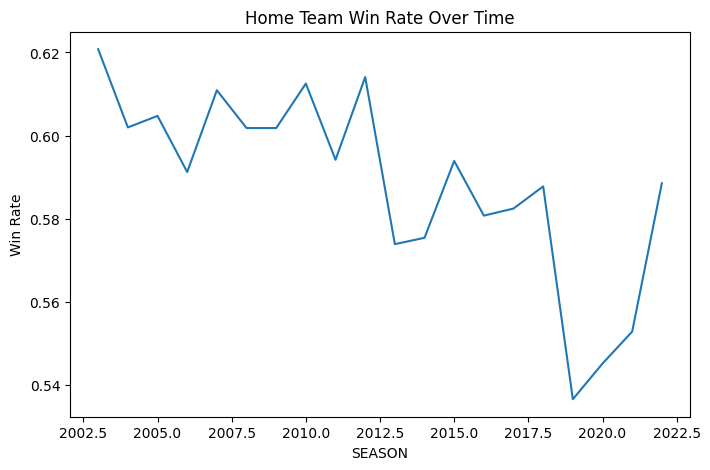

In [43]:
season_winrate = engineered_df.groupby("SEASON")["HOME_TEAM_WINS"].mean()

season_winrate.plot(figsize=(8,5))
plt.title("Home Team Win Rate Over Time")
plt.ylabel("Win Rate")
plt.show()

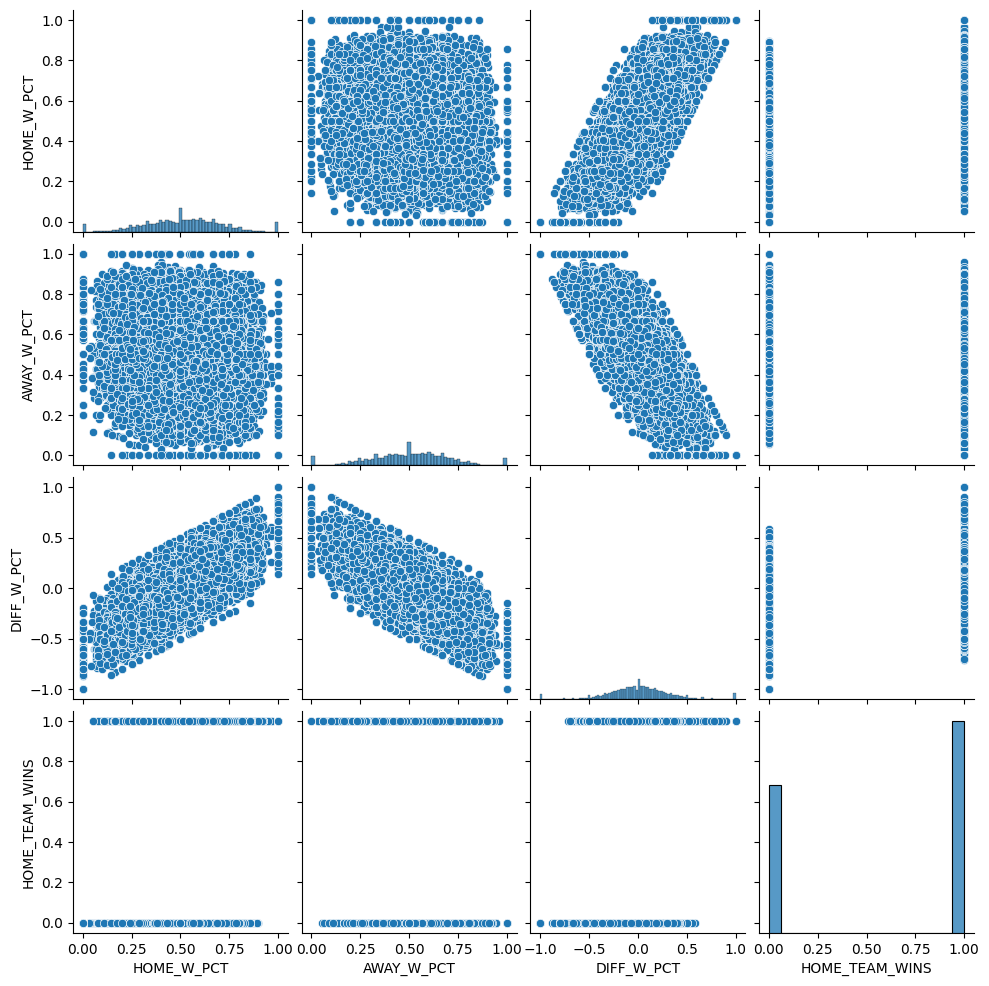

In [44]:
sns.pairplot(engineered_df[[
    "HOME_W_PCT",
    "AWAY_W_PCT",
    "DIFF_W_PCT",
    "HOME_TEAM_WINS"
]])
plt.show()

### 1.3. Preprocessing

Now I prepare the new dataset for use by our algorithms. First, I remove the rows where I do not have enough historical pre-game information yet. 
After that, I split the data further into input features (X) and the target variable (y):

The selected input features are all the features from the new dataset excluding:
- `HOME_TEAM_WINS`
- `GAME_DATE_EST` 
- `HOME_TEAM_ID`
- `VISITOR_TEAM_ID` 

The target variable is:
- `HOME_TEAM_WINS`

As you can see, I have also removed the Team IDs since they are not necessary because we already have historical data for the team that is not tied to their IDs anymore.

I also treat the identifiers as categorical variables rather than numerical values.

In [32]:
from sklearn.preprocessing import StandardScaler

# Removing rows where historical pre-game information is not available yet
engineered_df = engineered_df.dropna().reset_index(drop=True)

# Defining features and target
drop_cols = [
    "HOME_TEAM_WINS",
    "GAME_DATE_EST",
    "HOME_TEAM_ID",
    "VISITOR_TEAM_ID"
]
X = engineered_df.drop(columns=drop_cols)
y = engineered_df["HOME_TEAM_WINS"]

# Scaling features (fit later on train only, but defined scaler here)
scaler = StandardScaler()

print("Feature matrix shape:", X.shape)
print("Missing values:", engineered_df.isnull().sum().sum())

Feature matrix shape: (26488, 14)
Missing values: 0


### 1.4. Train-Test Split

Here, I split the dataset into a training set and a test set. As learned in the lessons, I use 80% of the data for training and 20% for testing.

This is a bit more complex with my dataset. Because I need the data to be chronological to ensure that the model is only trained on historical data before the games in the test set (preventing data leakage).

I can see that the data is slightly imbalanced (approximately 59% wins and 41% losses), but this should not be a major issue at this stage.

In [30]:
y.value_counts(normalize=True)

HOME_TEAM_WINS
1    0.588984
0    0.411016
Name: proportion, dtype: float64

In [ ]:
# Create time-based 80/20 split
split_date = engineered_df["GAME_DATE_EST"].quantile(0.8)

train = engineered_df[engineered_df["GAME_DATE_EST"] < split_date].copy()
test  = engineered_df[engineered_df["GAME_DATE_EST"] >= split_date].copy()

# Split into features and target
X_train = train.drop(columns=drop_cols)
y_train = train["HOME_TEAM_WINS"]

X_test = test.drop(columns=drop_cols)
y_test = test["HOME_TEAM_WINS"]

# Scale (fit ONLY on training data)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check shapes
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# Check distribution
print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

# Check split date
print("\nSplit date:", split_date)

Training set: (21320, 3)
Test set: (5331, 3)

Train distribution:
 HOME_TEAM_WINS
1    0.587054
0    0.412946
Name: proportion, dtype: float64

Test distribution:
 HOME_TEAM_WINS
1    0.586944
0    0.413056
Name: proportion, dtype: float64


### 1.5. Benchmark Model

As defined in the project brief, I use logistic regression as the benchmark model.

I standardised the features since logistic regression usually does not perform well with differences in scale. I used __TimeSeriesSplit with 5 folds__ to prevent the model from peeking into the future whilst training (ensuring it is trained on the data in chronological order).

As we can see from the output, the model achieves a mean cross-validation accuracy of approximately 75.4%, with a low standard deviation of about 0.7% across the five folds. This stable performance indicates that the features I engineered in the previous step work fairly well.

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Time-aware cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Benchmark pipeline
benchmark_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

# 5-fold time-series cross-validation on training data
cv_scores = cross_val_score(
    benchmark_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="accuracy"
)

print("TimeSeriesSplit accuracy scores:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Standard deviation:", np.std(cv_scores))

TimeSeriesSplit accuracy scores: [0.7499292  0.76777117 0.75134523 0.74907958 0.7499292 ]
Mean CV accuracy: 0.7536108751062023
Standard deviation: 0.007117432270722067


### 1.6. Compare Models with Cross-Validation

Now I evaluate with two additional classification models: Decision Tree and Random Forest.

These models are chosen to compare other approaches:
- **Logistic Regression** provides a simple linear baseline.
- **Decision Tree** can capture non-linear decision boundaries.
- **Random Forest** combines multiple decision trees.

Again, I evaluated all the models using __5-fold TimeSeriesSplit cross-validation__ on the training set. I print the mean accuracy and the standard deviation for each model in the end. 

I then choose the best model based on these cross-validation results.

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Time-aware cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Defining models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000))
    ]),
    "Decision Tree": Pipeline([
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("classifier", RandomForestClassifier(random_state=42))
    ])
}

# Evaluating all models with TimeSeriesSplit
results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring="accuracy"
    )
    results[name] = {
        "scores": scores,
        "mean_accuracy": scores.mean(),
        "std_accuracy": scores.std()
    }

# Print results
for name, result in results.items():
    print(name)
    print("Scores:", result["scores"])
    print("Mean accuracy:", result["mean_accuracy"])
    print("Standard deviation:", result["std_accuracy"])
    print("-" * 50)

Logistic Regression
Scores: [0.7499292  0.76777117 0.75134523 0.74907958 0.7499292 ]
Mean accuracy: 0.7536108751062023
Standard deviation: 0.007117432270722067
--------------------------------------------------
Decision Tree
Scores: [0.66440102 0.68365902 0.67884452 0.66100255 0.65703767]
Mean accuracy: 0.6689889549702633
Standard deviation: 0.010392382841057809
--------------------------------------------------
Random Forest
Scores: [0.73293685 0.74907958 0.7451147  0.71962617 0.73208723]
Mean accuracy: 0.7357689039932029
Standard deviation: 0.010456397176291675
--------------------------------------------------


#### 1.6.1. Model Comparison Results

I can see a clear difference based on the three models:

1. __Logistic regression__: Performs best, with a mean accuracy of ~75.4% and a low standard deviation of ~0.7%. This indicates a stable and reasonably strong model.
2. __Random forest__: Performs slightly worse than logistic regression, with a mean accuracy of ~73.6% and a standard deviation of ~1%.
3. __Decision tree__: Performs the worst, with a mean accuracy of ~66.9% and a standard deviation of ~1%. This suggests that a single tree is insufficient to capture reliable patterns.

Overall, we can see that logistic regression outperforms the more complex models. It is more accurate and also more stable. This suggests that the correlation of the features is more linear, and more complex models do not necessarily lead to better outcomes.

### 1.7. Final Evaluation on Test Set

Now that I have identified logistic regression as the best model based on time-series cross-validation, it is time to train it on the full training dataset.

I then evaluate the model on the test set. There, we have future games that have not yet been seen by the model. As mentioned before, this aims to imitate a realistic scenario without any data leakage.

I use the test accuracy and the classification report to assess the final performance of the model.

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Selecting Logistic Regression as Final model (same as benchmark)
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train on full training data
best_model.fit(X_train, y_train)

# Predict on test set
y_pred = best_model.predict(X_test)

# Evaluate
test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7400906002265005

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.66      0.69      2352
           1       0.75      0.80      0.77      2946

    accuracy                           0.74      5298
   macro avg       0.74      0.73      0.73      5298
weighted avg       0.74      0.74      0.74      5298



### 1.8. Interpretation & Conclusion

--
